In [1]:
import pandas as pd

train_df = pd.read_csv(r"C:\Users\hp\Downloads\sent_train.csv")
valid_df = pd.read_csv(r"C:\Users\hp\Downloads\sent_valid.csv")

print(train_df.head())
print(train_df.shape)
print(valid_df.shape)

                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0
(9543, 2)
(2388, 2)


In [2]:
print(train_df.info())

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nLabel Distribution:")
print(train_df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB
None

Missing Values:
text     0
label    0
dtype: int64

Label Distribution:
label
2    6178
1    1923
0    1442
Name: count, dtype: int64


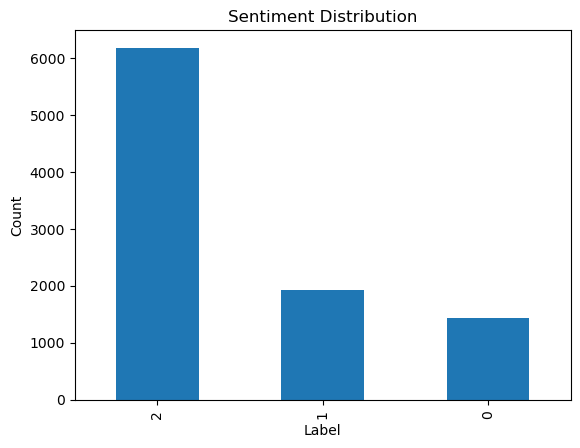

In [3]:
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
valid_df["clean_text"] = valid_df["text"].apply(clean_text)

train_df[["text","clean_text"]].head()

,text,clean_text
0,$BYND - JPMorgan reels in expectations on Beyo...,bynd jpmorgan reels in expectations on beyond ...
1,$CCL $RCL - Nomura points to bookings weakness...,ccl rcl nomura points to bookings weakness at ...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",cx cemex cut at credit suisse jp morgan on wea...
3,$ESS: BTIG Research cuts to Neutral https://t....,ess btig research cuts to neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,fnko funko slides after piper jaffray pt cut


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df["clean_text"])

X_train = tokenizer.texts_to_sequences(train_df["clean_text"])
X_valid = tokenizer.texts_to_sequences(valid_df["clean_text"])

X_train = pad_sequences(X_train, maxlen=max_len)
X_valid = pad_sequences(X_valid, maxlen=max_len)

y_train = train_df["label"]
y_valid = valid_df["label"]

print(X_train.shape)
print(X_valid.shape)

(9543, 100)
(2388, 100)


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=5,
    batch_size=32
)

Epoch 1/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9801 - loss: 0.0623 - val_accuracy: 0.7885 - val_loss: 0.9842
Epoch 2/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9826 - loss: 0.0521 - val_accuracy: 0.8011 - val_loss: 1.0687
Epoch 3/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9872 - loss: 0.0412 - val_accuracy: 0.8061 - val_loss: 1.0976
Epoch 4/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.8028 - val_loss: 1.2919
Epoch 5/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.7977 - val_loss: 1.3929


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.save("financial_news_sentiment_model.h5")
print("Model Saved Successfully")

Model Saved Successfully
